In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U openai-whisper yt-dlp spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 13.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.2 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=fe0eb95fa94cd010d0fdd593d3ff0f3508a1853cdc31124df58b7eac7aa23c24
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 25.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupy

## Português

In [4]:
!python -m spacy download pt_core_news_md

  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_md-3.8.0/pt_core_news_md-3.8.0-py3-none-any.whl (42.4 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Por sentença

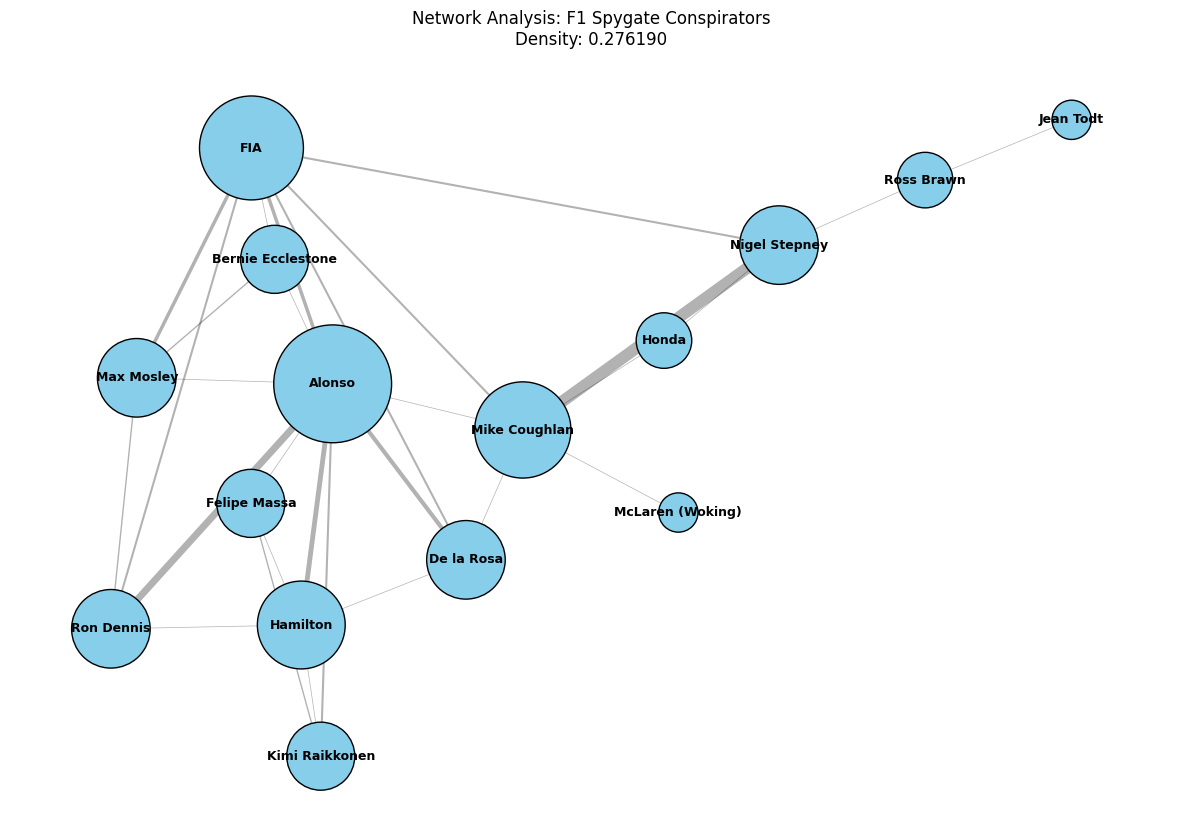

In [6]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re
nlp = spacy.load("pt_core_news_md")


whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_pt = nx.Graph()

merged_txt = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/merged_transcripts_v2.txt"
with open(merged_txt, 'r', encoding='utf-8') as f:
  texto_completo = f.read()

doc = nlp(texto_completo)
nlp.max_length = len(texto_completo) + 1000

for sent in doc.sents:
  ents_na_frase = []
  for termo in whitelist_estrita:
    if re.search(rf'\b{re.escape(termo)}\b', sent.text, re.IGNORECASE):
      ents_na_frase.append(mapeamento_nomes[termo])

  ents_na_frase = list(set(ents_na_frase))
  for i in range(len(ents_na_frase)):
    for j in range(i+1, len(ents_na_frase)):
      u, v = ents_na_frase[i], ents_na_frase[j]
      if G_pt.has_edge(u,v):
        G_pt[u][v]['weight'] += 1
      else:
        G_pt.add_edge(u, v, weight=1)


plt.figure(figsize=(15, 10))
# Usar o layout Kamada-Kawai ajuda a evitar a sobreposição de nomes
pos = nx.kamada_kawai_layout(G_pt)


graus = dict(G_pt.degree())

nx.draw_networkx_nodes(G_pt, pos, node_size=[v * 800 for v in graus.values()], node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(G_pt, pos, alpha=0.3, edge_color='black', width=[G_pt[u][v]['weight']*0.5 for u, v in G_pt.edges()])
nx.draw_networkx_labels(G_pt, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis: F1 Spygate Conspirators\nDensity: {nx.density(G_pt):.6f}")
plt.axis('off')
plt.show()

nx.write_graphml(G_pt, "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_pt-ver1.graphml")

Por paragrafo

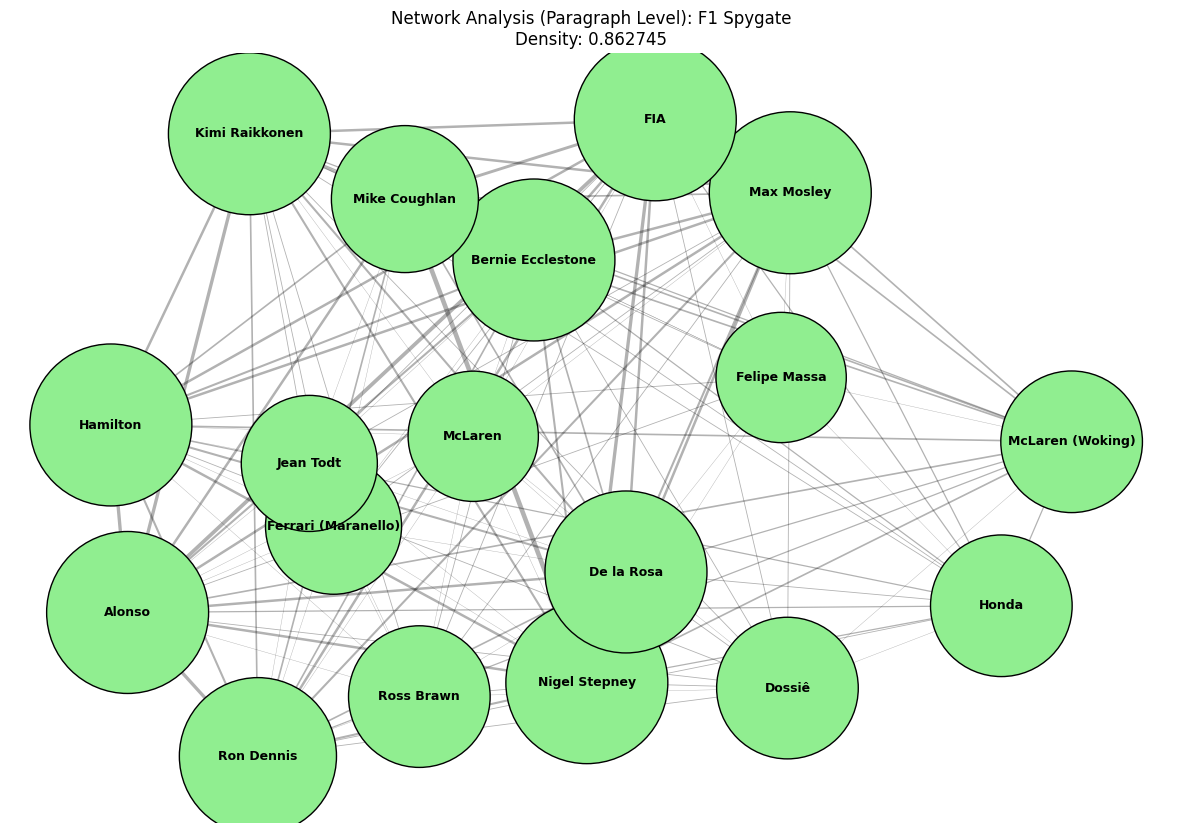

In [11]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re

# Carregamos o nlp apenas se precisar de outras funções do spacy,
# mas para parágrafos usaremos split direto na string.
nlp = spacy.load("pt_core_news_md")

whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]

mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_pt_paragrafo = nx.Graph()

merged_txt = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/merged_transcripts_v2.txt"
with open(merged_txt, 'r', encoding='utf-8') as f:
    texto_completo = f.read()

# Divisão por parágrafos (remove espaços em branco e parágrafos vazios)
paragrafos = [p for p in texto_completo.split('\n') if p.strip()]

for paragrafo in paragrafos:
    ents_no_paragrafo = []
    for termo in whitelist_estrita:
        # Busca o termo dentro do bloco do parágrafo
        if re.search(rf'\b{re.escape(termo)}\b', paragrafo, re.IGNORECASE):
            ents_no_paragrafo.append(mapeamento_nomes[termo])

    # Remove duplicatas de nomes que mapeiam para a mesma entidade no mesmo parágrafo
    ents_no_paragrafo = list(set(ents_no_paragrafo))

    # Criação das arestas baseada na co-ocorrência no parágrafo
    for i in range(len(ents_no_paragrafo)):
        for j in range(i+1, len(ents_no_paragrafo)):
            u, v = ents_no_paragrafo[i], ents_no_paragrafo[j]
            if G_pt_paragrafo.has_edge(u,v):
                G_pt_paragrafo[u][v]['weight'] += 1
            else:
                G_pt_paragrafo.add_edge(u, v, weight=1)

# Visualização
plt.figure(figsize=(15, 10))
pos = nx.kamada_kawai_layout(G_pt_paragrafo)
graus = dict(G_pt_paragrafo.degree())

nx.draw_networkx_nodes(G_pt_paragrafo, pos,
                       node_size=[v * 800 for v in graus.values()],
                       node_color='lightgreen',
                       edgecolors='black')

nx.draw_networkx_edges(G_pt_paragrafo, pos, alpha=0.3,
                       edge_color='black',
                       width=[G_pt_paragrafo[u][v]['weight']*0.3 for u, v in G_pt_paragrafo.edges()])

nx.draw_networkx_labels(G_pt_paragrafo, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis (Paragraph Level): F1 Spygate\nDensity: {nx.density(G_pt_paragrafo):.6f}")
plt.axis('off')
plt.show()

# Exportação (Ajustado o nome do arquivo para diferenciar da versão por sentença)
output_path = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_pt-paragrafos.graphml"
nx.write_graphml(G_pt_paragrafo, output_path)

Por janela de caracter

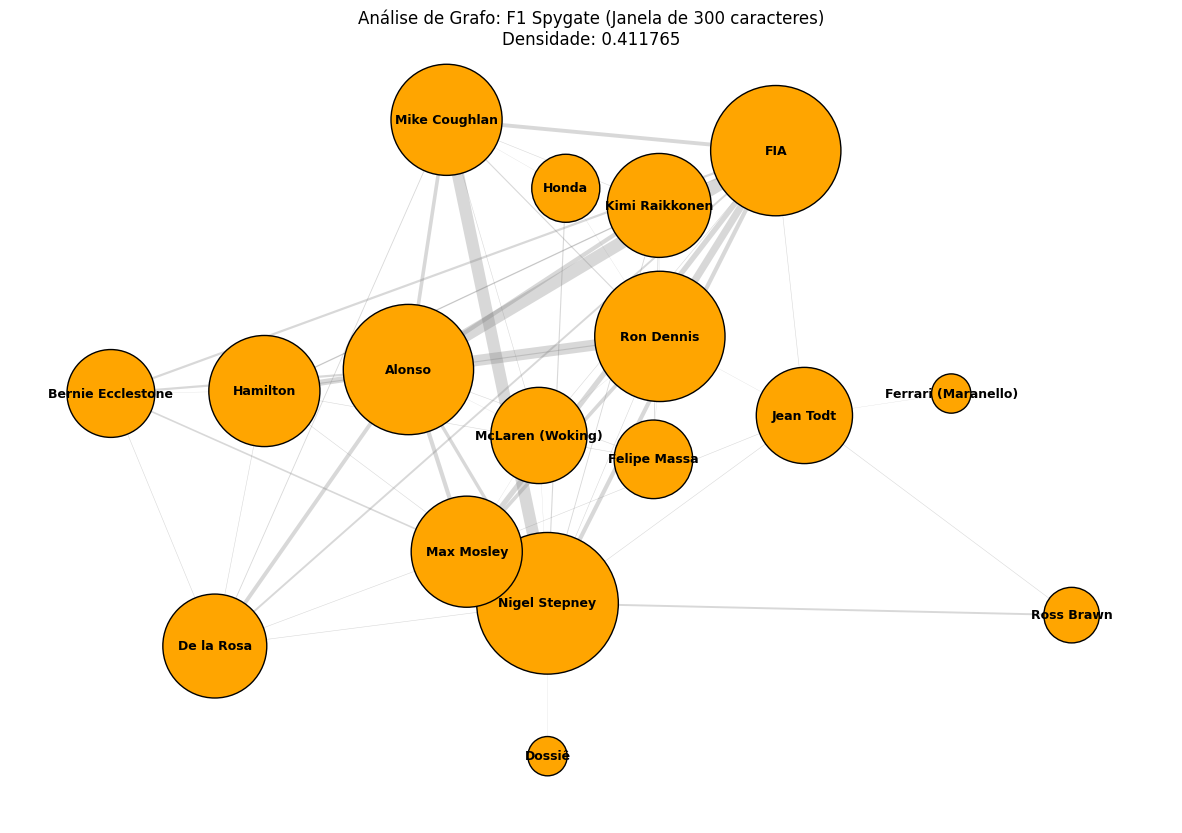

Grafo gerado com sucesso! Salvo em: /content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_janela_300.graphml


In [13]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re

# Carregamento do modelo (necessário para manter o padrão, embora a divisão seja por caracteres)
nlp = spacy.load("pt_core_news_md")

# --- CONFIGURAÇÕES DA JANELA ---
TAMANHO_JANELA = 300  # Intervalo de 300 caracteres como solicitado
PASSO = 150          # Deslocamento (overlap de 50% para não perder entidades nos cortes)

# Dicionário de mapeamento original
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney", "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan", "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso", "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa", "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton", "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari", "McLaren Mercedes": "McLaren",
    "FIA": "FIA", "WMSC": "FIA", "780-page dossier": "Dossiê",
    "Honda": "Honda", "Felipe Massa": "Felipe Massa", "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley", "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone", "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore", "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo", "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)", "Dossier": "Dossiê", "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_janela = nx.Graph()

# Caminho do arquivo unificado
merged_txt = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/merged_transcripts_v2.txt"

with open(merged_txt, 'r', encoding='utf-8') as f:
    texto_completo = f.read()

# --- LÓGICA DE JANELA DESLIZANTE (CADEIA DE CARACTERES) ---
# Percorre o texto em blocos de 300 caracteres
for i in range(0, len(texto_completo), PASSO):
    # Extrai o trecho (cadeia) de texto do intervalo atual
    janela_texto = texto_completo[i : i + TAMANHO_JANELA]

    ents_na_janela = []
    for termo in whitelist_estrita:
        # Busca por termos exatos (\b) dentro dos 300 caracteres
        if re.search(rf'\b{re.escape(termo)}\b', janela_texto, re.IGNORECASE):
            ents_na_janela.append(mapeamento_nomes[termo])

    # Remove duplicatas (ex: "Alonso" e "Fernando Alonso" no mesmo bloco contam como uma única entidade)
    ents_na_janela = list(set(ents_na_janela))

    # Cria as arestas (conexões) entre as entidades que apareceram nestes 300 caracteres
    for i_ent in range(len(ents_na_janela)):
        for j_ent in range(i_ent + 1, len(ents_na_janela)):
            u, v = ents_na_janela[i_ent], ents_na_janela[j_ent]
            if G_janela.has_edge(u, v):
                G_janela[u][v]['weight'] += 1
            else:
                G_janela.add_edge(u, v, weight=1)

# --- VISUALIZAÇÃO ---
plt.figure(figsize=(15, 10))
pos = nx.kamada_kawai_layout(G_janela)
graus = dict(G_janela.degree())

# Desenha nós (tamanho proporcional ao grau/importância)
nx.draw_networkx_nodes(G_janela, pos,
                       node_size=[v * 800 for v in graus.values()],
                       node_color='orange',
                       edgecolors='black')

# Desenha arestas (espessura baseada no peso/frequência de co-ocorrência)
nx.draw_networkx_edges(G_janela, pos, alpha=0.3,
                       edge_color='gray',
                       width=[G_janela[u][v]['weight'] * 0.2 for u, v in G_janela.edges()])

nx.draw_networkx_labels(G_janela, pos, font_size=9, font_weight="bold")

plt.title(f"Análise de Grafo: F1 Spygate (Janela de {TAMANHO_JANELA} caracteres)\nDensidade: {nx.density(G_janela):.6f}")
plt.axis('off')
plt.show()

# --- EXPORTAÇÃO ---
output_path = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_janela_300.graphml"
nx.write_graphml(G_janela, output_path)

print(f"Grafo gerado com sucesso! Salvo em: {output_path}")

## Inglês

In [8]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 16.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


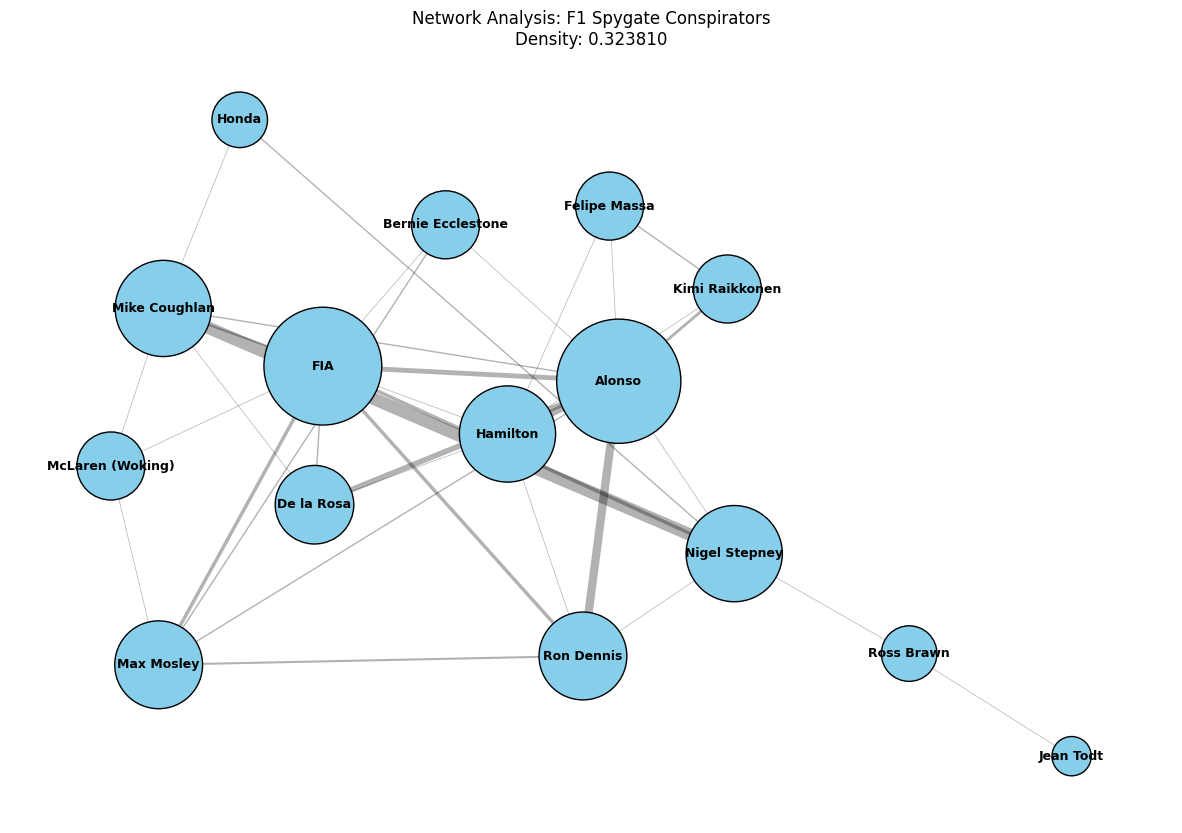

In [10]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re
nlp = spacy.load("en_core_web_md")


whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_pt = nx.Graph()

merged_txt = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/merged_transcripts_v2.txt"
with open(merged_txt, 'r', encoding='utf-8') as f:
  texto_completo = f.read()

doc = nlp(texto_completo)
nlp.max_length = len(texto_completo) + 1000

for sent in doc.sents:
  ents_na_frase = []
  for termo in whitelist_estrita:
    if re.search(rf'\b{re.escape(termo)}\b', sent.text, re.IGNORECASE):
      ents_na_frase.append(mapeamento_nomes[termo])

  ents_na_frase = list(set(ents_na_frase))
  for i in range(len(ents_na_frase)):
    for j in range(i+1, len(ents_na_frase)):
      u, v = ents_na_frase[i], ents_na_frase[j]
      if G_pt.has_edge(u,v):
        G_pt[u][v]['weight'] += 1
      else:
        G_pt.add_edge(u, v, weight=1)


plt.figure(figsize=(15, 10))
# Usar o layout Kamada-Kawai ajuda a evitar a sobreposição de nomes
pos = nx.kamada_kawai_layout(G_pt)


graus = dict(G_pt.degree())

nx.draw_networkx_nodes(G_pt, pos, node_size=[v * 800 for v in graus.values()], node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(G_pt, pos, alpha=0.3, edge_color='black', width=[G_pt[u][v]['weight']*0.5 for u, v in G_pt.edges()])
nx.draw_networkx_labels(G_pt, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis: F1 Spygate Conspirators\nDensity: {nx.density(G_pt):.6f}")
plt.axis('off')
plt.show()

nx.write_graphml(G_pt, "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_en-ver1.graphml")

Por paragrafo

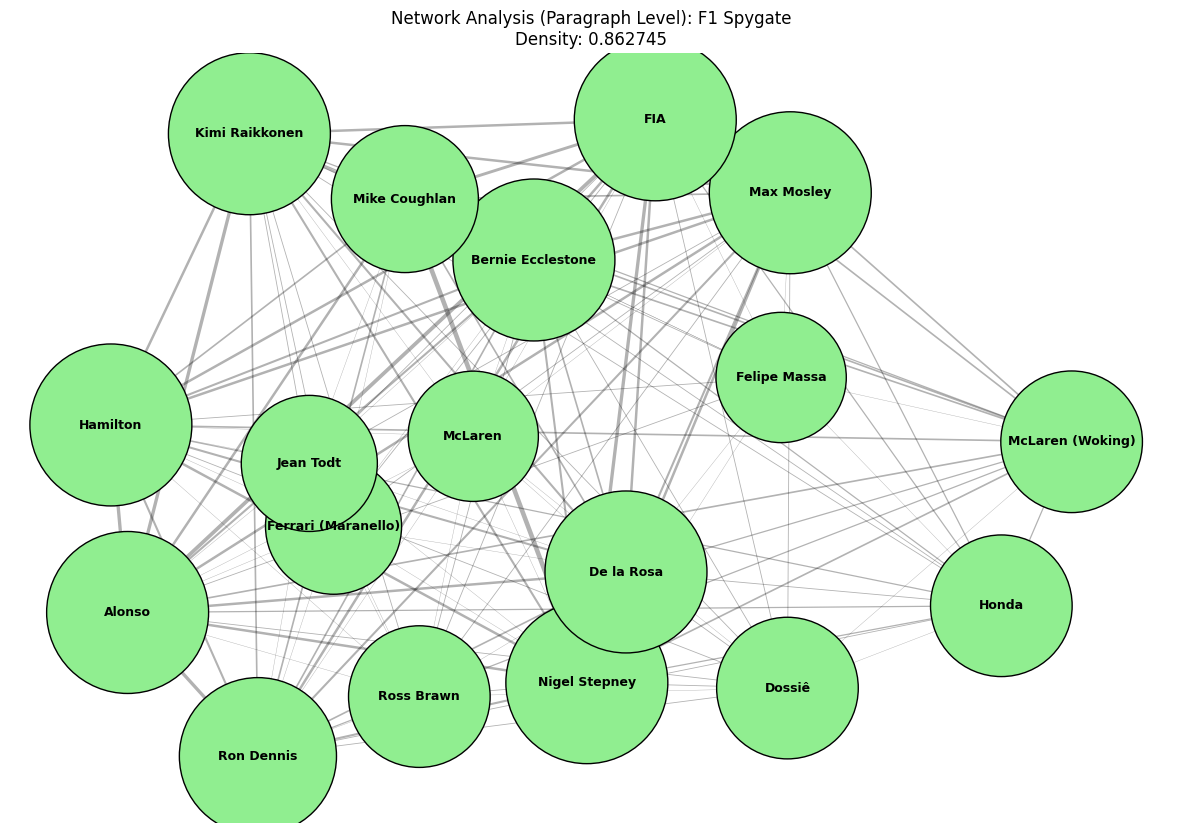

In [12]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re

# Carregamos o nlp apenas se precisar de outras funções do spacy,
# mas para parágrafos usaremos split direto na string.
nlp = spacy.load("en_core_web_md")

whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]

mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_pt_paragrafo = nx.Graph()

merged_txt = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/merged_transcripts_v2.txt"
with open(merged_txt, 'r', encoding='utf-8') as f:
    texto_completo = f.read()

# Divisão por parágrafos (remove espaços em branco e parágrafos vazios)
paragrafos = [p for p in texto_completo.split('\n') if p.strip()]

for paragrafo in paragrafos:
    ents_no_paragrafo = []
    for termo in whitelist_estrita:
        # Busca o termo dentro do bloco do parágrafo
        if re.search(rf'\b{re.escape(termo)}\b', paragrafo, re.IGNORECASE):
            ents_no_paragrafo.append(mapeamento_nomes[termo])

    # Remove duplicatas de nomes que mapeiam para a mesma entidade no mesmo parágrafo
    ents_no_paragrafo = list(set(ents_no_paragrafo))

    # Criação das arestas baseada na co-ocorrência no parágrafo
    for i in range(len(ents_no_paragrafo)):
        for j in range(i+1, len(ents_no_paragrafo)):
            u, v = ents_no_paragrafo[i], ents_no_paragrafo[j]
            if G_pt_paragrafo.has_edge(u,v):
                G_pt_paragrafo[u][v]['weight'] += 1
            else:
                G_pt_paragrafo.add_edge(u, v, weight=1)

# Visualização
plt.figure(figsize=(15, 10))
pos = nx.kamada_kawai_layout(G_pt_paragrafo)
graus = dict(G_pt_paragrafo.degree())

nx.draw_networkx_nodes(G_pt_paragrafo, pos,
                       node_size=[v * 800 for v in graus.values()],
                       node_color='lightgreen',
                       edgecolors='black')

nx.draw_networkx_edges(G_pt_paragrafo, pos, alpha=0.3,
                       edge_color='black',
                       width=[G_pt_paragrafo[u][v]['weight']*0.3 for u, v in G_pt_paragrafo.edges()])

nx.draw_networkx_labels(G_pt_paragrafo, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis (Paragraph Level): F1 Spygate\nDensity: {nx.density(G_pt_paragrafo):.6f}")
plt.axis('off')
plt.show()

# Exportação (Ajustado o nome do arquivo para diferenciar da versão por sentença)
output_path = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_en-paragrafos.graphml"
nx.write_graphml(G_pt_paragrafo, output_path)

Por janela de caracter

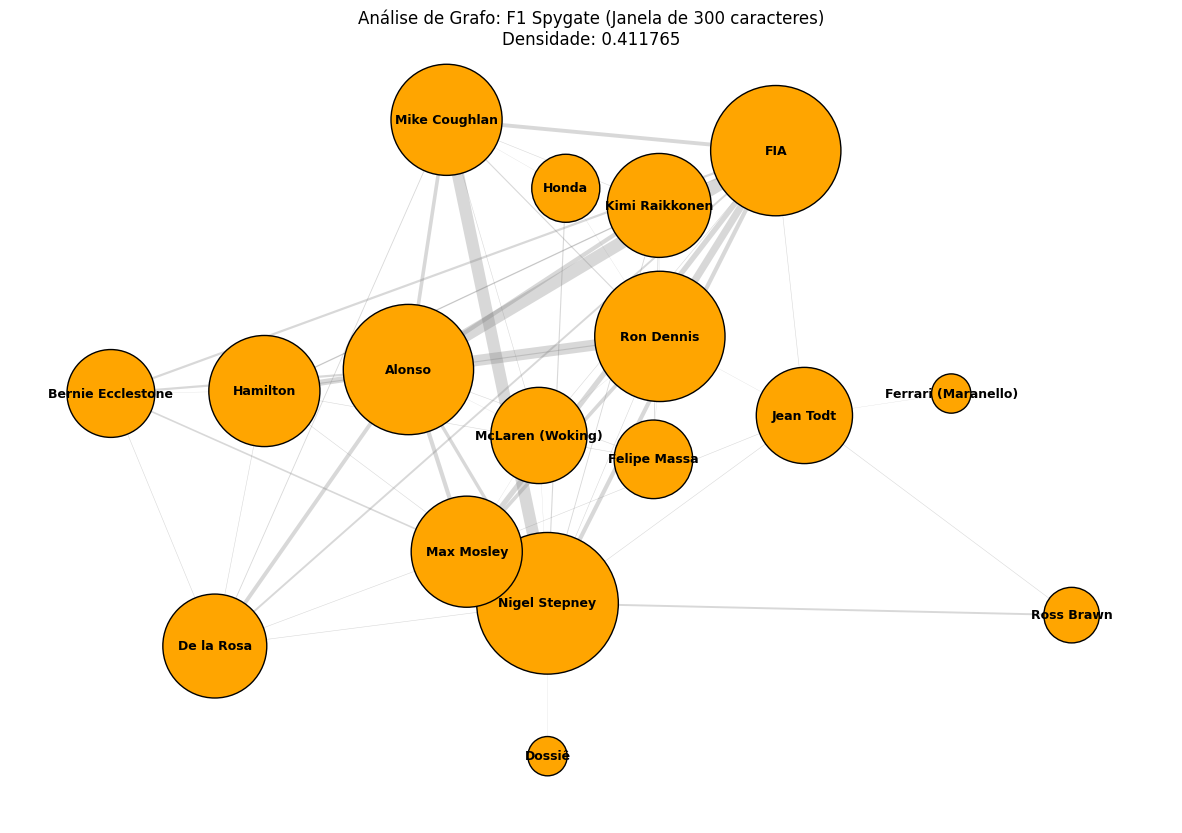

Grafo gerado com sucesso! Salvo em: /content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_janela_en_300.graphml


In [14]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re

# Carregamento do modelo (necessário para manter o padrão, embora a divisão seja por caracteres)
nlp = spacy.load("en_core_web_md")

# --- CONFIGURAÇÕES DA JANELA ---
TAMANHO_JANELA = 300  # Intervalo de 300 caracteres como solicitado
PASSO = 150          # Deslocamento (overlap de 50% para não perder entidades nos cortes)

# Dicionário de mapeamento original
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney", "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan", "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso", "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa", "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton", "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari", "McLaren Mercedes": "McLaren",
    "FIA": "FIA", "WMSC": "FIA", "780-page dossier": "Dossiê",
    "Honda": "Honda", "Felipe Massa": "Felipe Massa", "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley", "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone", "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore", "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo", "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)", "Dossier": "Dossiê", "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_janela = nx.Graph()

# Caminho do arquivo unificado
merged_txt = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/merged_transcripts_v2.txt"

with open(merged_txt, 'r', encoding='utf-8') as f:
    texto_completo = f.read()

# --- LÓGICA DE JANELA DESLIZANTE (CADEIA DE CARACTERES) ---
# Percorre o texto em blocos de 300 caracteres
for i in range(0, len(texto_completo), PASSO):
    # Extrai o trecho (cadeia) de texto do intervalo atual
    janela_texto = texto_completo[i : i + TAMANHO_JANELA]

    ents_na_janela = []
    for termo in whitelist_estrita:
        # Busca por termos exatos (\b) dentro dos 300 caracteres
        if re.search(rf'\b{re.escape(termo)}\b', janela_texto, re.IGNORECASE):
            ents_na_janela.append(mapeamento_nomes[termo])

    # Remove duplicatas (ex: "Alonso" e "Fernando Alonso" no mesmo bloco contam como uma única entidade)
    ents_na_janela = list(set(ents_na_janela))

    # Cria as arestas (conexões) entre as entidades que apareceram nestes 300 caracteres
    for i_ent in range(len(ents_na_janela)):
        for j_ent in range(i_ent + 1, len(ents_na_janela)):
            u, v = ents_na_janela[i_ent], ents_na_janela[j_ent]
            if G_janela.has_edge(u, v):
                G_janela[u][v]['weight'] += 1
            else:
                G_janela.add_edge(u, v, weight=1)

# --- VISUALIZAÇÃO ---
plt.figure(figsize=(15, 10))
pos = nx.kamada_kawai_layout(G_janela)
graus = dict(G_janela.degree())

# Desenha nós (tamanho proporcional ao grau/importância)
nx.draw_networkx_nodes(G_janela, pos,
                       node_size=[v * 800 for v in graus.values()],
                       node_color='orange',
                       edgecolors='black')

# Desenha arestas (espessura baseada no peso/frequência de co-ocorrência)
nx.draw_networkx_edges(G_janela, pos, alpha=0.3,
                       edge_color='gray',
                       width=[G_janela[u][v]['weight'] * 0.2 for u, v in G_janela.edges()])

nx.draw_networkx_labels(G_janela, pos, font_size=9, font_weight="bold")

plt.title(f"Análise de Grafo: F1 Spygate (Janela de {TAMANHO_JANELA} caracteres)\nDensidade: {nx.density(G_janela):.6f}")
plt.axis('off')
plt.show()

# --- EXPORTAÇÃO ---
output_path = "/content/drive/MyDrive/Disciplinas 2026.1/ED2/Proj-1/Merged-ver/spygate_graph_janela_en_300.graphml"
nx.write_graphml(G_janela, output_path)

print(f"Grafo gerado com sucesso! Salvo em: {output_path}")